# Assignment 5 – RNN, LSTM and GRU

This notebook uses AAPL historical closing prices to classify the next trading day's price direction as UP (1) or DOWN (0) using SimpleRNN, LSTM and GRU models.

In [4]:
# Install yfinance for downloading stock market data
!pip install yfinance -q

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf

# Scikit-learn utilities
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds so that results are more reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Download Apple (AAPL) historical stock data
# The assignment uses data from January 2015 to January 2025

df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=False
)

# Display the first five rows
print("First five rows:")
display(df.head())

# Display dataset shape
print("\nDataset Shape:", df.shape)

[*********************100%***********************]  1 of 1 completed

First five rows:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490795,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493015,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822437,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000



Dataset Shape: (2516, 6)


In [6]:
# Display basic information about the dataset

print("Dataset Information:")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
Number of rows: 2516
Number of columns: 6

Columns:
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Missing Values:
Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64


In [7]:
# Extract only the closing price of AAPL
close_price = df["Close"].squeeze()

# Display statistical summary
print("Closing Price Statistics:")
print(close_price.describe())

Closing Price Statistics:
count    2516.000000
mean       96.363971
std        65.255230
min        22.584999
25%        37.639375
50%        66.661251
75%       152.772503
max       259.019989
Name: AAPL, dtype: float64


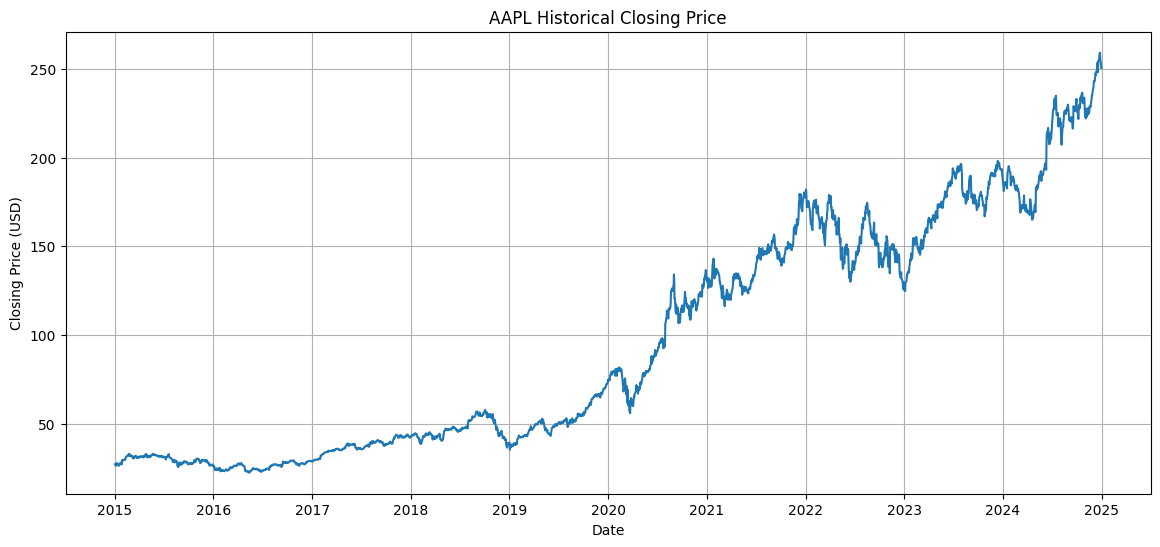

In [8]:
# Plot AAPL historical closing prices

plt.figure(figsize=(14, 6))

plt.plot(close_price)

plt.title("AAPL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.grid(True)
plt.show()

In [9]:
# Create the target variable
#
# Target:
# 1 -> Next day's closing price is higher than today's
# 0 -> Next day's closing price is lower than or equal to today's

next_day_price = close_price.shift(-1)

target = (next_day_price > close_price).astype(int)

# Remove the final row because there is no next-day price for it
close_price = close_price.iloc[:-1]
target = target.iloc[:-1]

print("Target variable created successfully.")

print("\nTarget distribution:")
print(target.value_counts())

print("\nTarget distribution in percentage:")
print(target.value_counts(normalize=True) * 100)

Target variable created successfully.

Target distribution:
AAPL
1    1336
0    1179
Name: count, dtype: int64

Target distribution in percentage:
AAPL
1    53.121272
0    46.878728
Name: proportion, dtype: float64


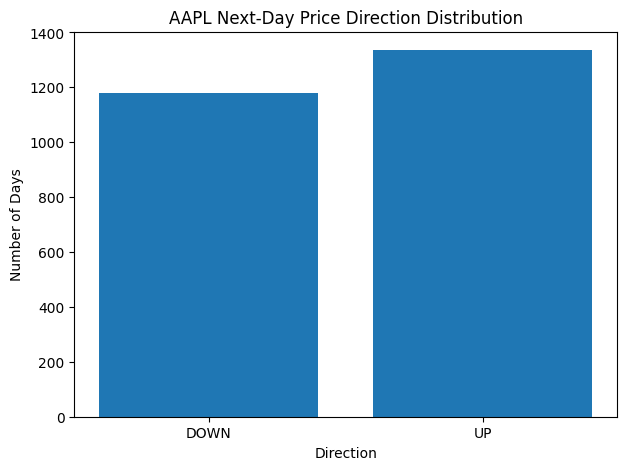

DOWN days: 1179
UP days: 1336


In [10]:
# Count the number of DOWN and UP days

down_count = (target == 0).sum()
up_count = (target == 1).sum()

labels = ["DOWN", "UP"]
values = [down_count, up_count]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.title("AAPL Next-Day Price Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Number of Days")

plt.show()

print("DOWN days:", down_count)
print("UP days:", up_count)

In [11]:
# Number of previous trading days used as input
time_step = 30

# Convert closing prices and target into NumPy arrays
data = close_price.values.reshape(-1, 1)
targets = target.values

print("Total observations:", len(data))
print("Time step:", time_step)

Total observations: 2515
Time step: 30


In [12]:
# Use the first 80% of the data for training
# and the remaining 20% for testing.

split_index = int(len(data) * 0.8)

train_data = data[:split_index]
test_data = data[split_index:]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))
print("Split index:", split_index)

Training observations: 2012
Testing observations: 503
Split index: 2012


In [13]:
# Create the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler ONLY on training data
train_scaled = scaler.fit_transform(train_data)

# Transform test data using the same scaler
test_scaled = scaler.transform(test_data)

print("Training data scaled successfully.")
print("Testing data scaled using the training scaler.")

Training data scaled successfully.
Testing data scaled using the training scaler.


In [14]:
# Create sequences for the training dataset

X_train = []
y_train = []

for i in range(time_step, len(train_scaled)):

    # Previous 30 days are used as input
    X_train.append(
        train_scaled[i-time_step:i, 0]
    )

    # Direction of the current day is the target
    y_train.append(
        targets[i]
    )

# Convert lists to NumPy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape before reshaping:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape before reshaping: (1982, 30)
y_train shape: (1982,)


In [15]:
# Combine the last 30 training observations with test data
# so that the first test sequence has enough historical context.

test_input = np.concatenate(
    [train_scaled[-time_step:], test_scaled]
)

X_test = []
y_test = []

for i in range(time_step, len(test_input)):

    # Previous 30 days
    X_test.append(
        test_input[i-time_step:i, 0]
    )

    # Corresponding target
    y_test.append(
        targets[split_index + i - time_step]
    )

# Convert to NumPy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape before reshaping:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape before reshaping: (503, 30)
y_test shape: (503,)


In [16]:
# Reshape training data
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

# Reshape testing data
X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1982, 30, 1)
X_test shape: (503, 30, 1)
y_train shape: (1982,)
y_test shape: (503,)


In [17]:
# Check the distribution of classes in the training set

print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
1    1032
0     950
Name: count, dtype: int64

Testing class distribution:
1    282
0    221
Name: count, dtype: int64


In [18]:
# Calculate balanced class weights

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Convert the result into a dictionary
class_weight_dict = {
    int(class_label): float(weight)
    for class_label, weight in zip(
        np.unique(y_train),
        class_weights
    )
}

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: 1.043157894736842, 1: 0.9602713178294574}


In [19]:
# Build the SimpleRNN model

rnn_model = Sequential([

    # Input layer
    Input(shape=(time_step, 1)),

    # Simple RNN layer
    SimpleRNN(64),

    # Dropout to reduce overfitting
    Dropout(0.2),

    # Binary classification output
    Dense(1, activation="sigmoid")
])

# Compile the model
rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Stop training if validation loss stops improving

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train SimpleRNN
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5104 - loss: 0.6961 - val_accuracy: 0.4874 - val_loss: 0.6998
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4778 - loss: 0.6978 - val_accuracy: 0.4874 - val_loss: 0.6979
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4846 - loss: 0.6951 - val_accuracy: 0.4874 - val_loss: 0.6958
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5115 - loss: 0.6934 - val_accuracy: 0.4874 - val_loss: 0.6948
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5025 - loss: 0.6939 - val_accuracy: 0.4874 - val_loss: 0.6962
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5053 - loss: 0.6937 - val_accuracy: 0.5126 - val_loss: 0.6931
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4863 - loss: 0.6952 - val_accuracy: 0.4925 - val_loss: 0.6934
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5070 - loss: 0.6936 - val_accuracy: 0.4874 - v

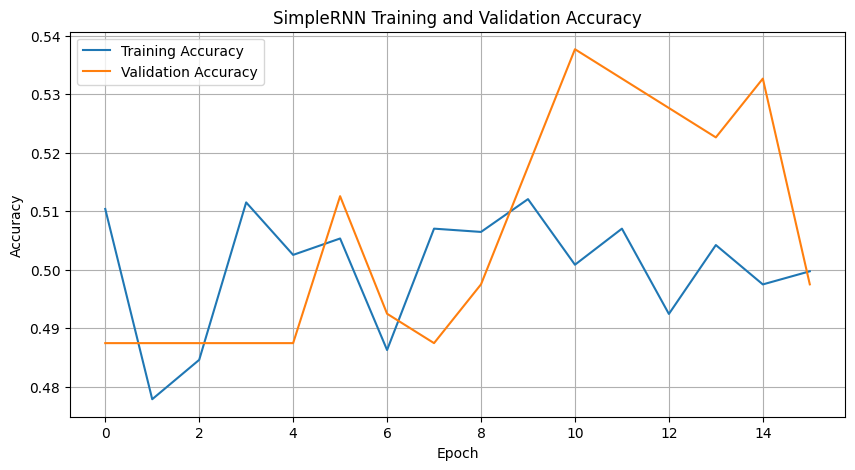

In [21]:
# Plot training and validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("SimpleRNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
# Build the LSTM model

lstm_model = Sequential([

    # Input layer
    Input(shape=(time_step, 1)),

    # LSTM layer
    LSTM(64),

    # Dropout for regularization
    Dropout(0.2),

    # Binary classification output
    Dense(1, activation="sigmoid")
])

# Compile the model
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the LSTM model

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4947 - loss: 0.6939 - val_accuracy: 0.5477 - val_loss: 0.6930
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5132 - loss: 0.6936 - val_accuracy: 0.5276 - val_loss: 0.6931
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5059 - loss: 0.6934 - val_accuracy: 0.5276 - val_loss: 0.6929
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5042 - loss: 0.6934 - val_accuracy: 0.5126 - val_loss: 0.6929
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5154 - loss: 0.6929 - val_accuracy: 0.5126 - val_loss: 0.6927


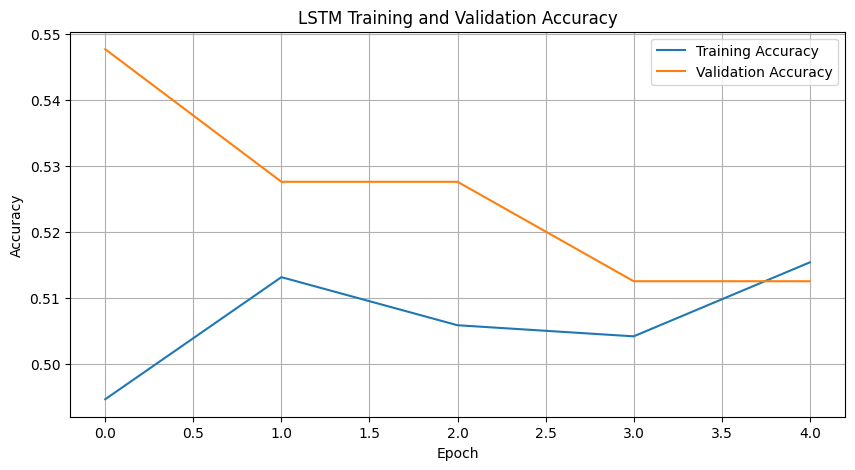

In [24]:
# Plot training and validation accuracy for LSTM

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
# Build the GRU model

gru_model = Sequential([

    # Input layer
    Input(shape=(time_step, 1)),

    # GRU layer
    GRU(64),

    # Dropout for regularization
    Dropout(0.2),

    # Binary classification output
    Dense(1, activation="sigmoid")
])

# Compile the model
gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train the GRU model

gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4762 - loss: 0.6945 - val_accuracy: 0.4975 - val_loss: 0.6931
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5222 - loss: 0.6935 - val_accuracy: 0.4874 - val_loss: 0.6932
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5137 - loss: 0.6933 - val_accuracy: 0.5126 - val_loss: 0.6928
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5036 - loss: 0.6939 - val_accuracy: 0.5226 - val_loss: 0.6929
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5048 - loss: 0.6935 - val_accuracy: 0.5276 - val_loss: 0.6929


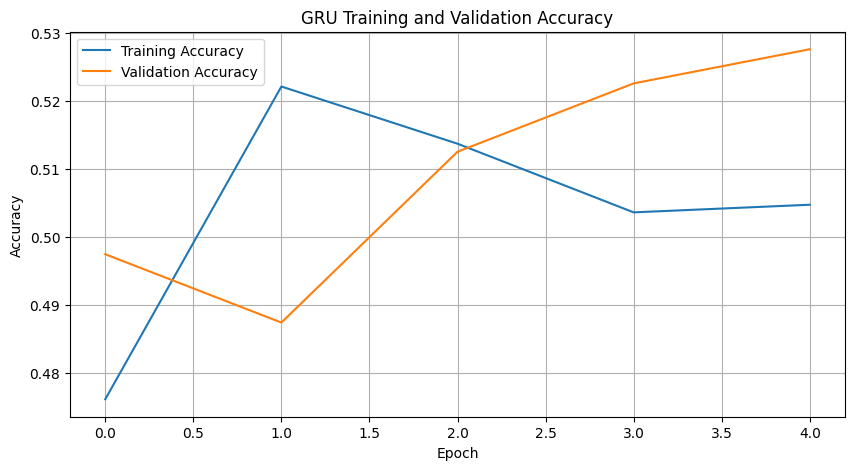

In [27]:
# Plot training and validation accuracy for GRU

plt.figure(figsize=(10, 5))

plt.plot(
    gru_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("GRU Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
# Generate probability predictions

rnn_prob = rnn_model.predict(X_test)
lstm_prob = lstm_model.predict(X_test)
gru_prob = gru_model.predict(X_test)

# Convert probabilities into binary predictions
# Probability >= 0.5 -> UP (1)
# Probability < 0.5 -> DOWN (0)

rnn_pred = (rnn_prob >= 0.5).astype(int).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int).flatten()
gru_pred = (gru_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predictions generated successfully.


In [29]:
# Calculate SimpleRNN evaluation metrics

rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_precision = precision_score(y_test, rnn_pred, zero_division=0)
rnn_recall = recall_score(y_test, rnn_pred, zero_division=0)
rnn_f1 = f1_score(y_test, rnn_pred, zero_division=0)

print("SimpleRNN Performance")
print("---------------------")
print("Accuracy :", rnn_accuracy)
print("Precision:", rnn_precision)
print("Recall   :", rnn_recall)
print("F1 Score :", rnn_f1)

SimpleRNN Performance
---------------------
Accuracy : 0.43737574552683894
Precision: 0.4
Recall   : 0.0070921985815602835
F1 Score : 0.013937282229965157


In [30]:
# Detailed classification report for SimpleRNN

print("SimpleRNN Classification Report:")
print(
    classification_report(
        y_test,
        rnn_pred,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

SimpleRNN Classification Report:
              precision    recall  f1-score   support

        DOWN       0.44      0.99      0.61       221
          UP       0.40      0.01      0.01       282

    accuracy                           0.44       503
   macro avg       0.42      0.50      0.31       503
weighted avg       0.42      0.44      0.27       503



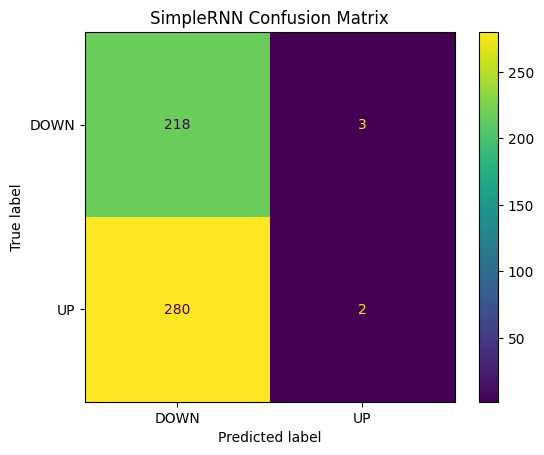

In [31]:
# Display SimpleRNN confusion matrix

cm_rnn = confusion_matrix(y_test, rnn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rnn,
    display_labels=["DOWN", "UP"]
)

disp.plot()

plt.title("SimpleRNN Confusion Matrix")
plt.show()

In [32]:
# Calculate LSTM evaluation metrics

lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred, zero_division=0)
lstm_recall = recall_score(y_test, lstm_pred, zero_division=0)
lstm_f1 = f1_score(y_test, lstm_pred, zero_division=0)

print("LSTM Performance")
print("----------------")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)

LSTM Performance
----------------
Accuracy : 0.4572564612326044
Precision: 0.6666666666666666
Recall   : 0.06382978723404255
F1 Score : 0.11650485436893204


In [33]:
# Detailed classification report for LSTM

print("LSTM Classification Report:")
print(
    classification_report(
        y_test,
        lstm_pred,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

LSTM Classification Report:
              precision    recall  f1-score   support

        DOWN       0.45      0.96      0.61       221
          UP       0.67      0.06      0.12       282

    accuracy                           0.46       503
   macro avg       0.56      0.51      0.36       503
weighted avg       0.57      0.46      0.33       503



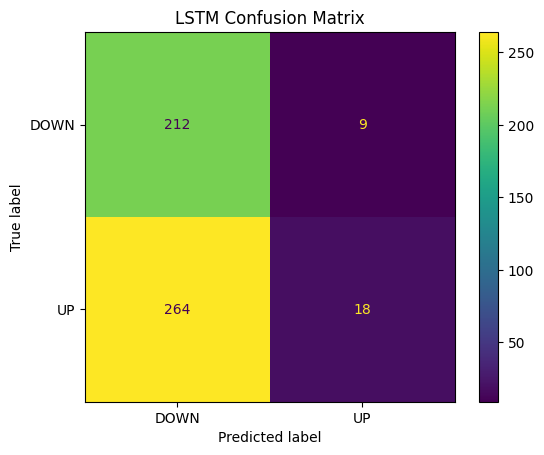

In [34]:
# Display LSTM confusion matrix

cm_lstm = confusion_matrix(y_test, lstm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["DOWN", "UP"]
)

disp.plot()

plt.title("LSTM Confusion Matrix")
plt.show()

In [35]:
# Calculate GRU evaluation metrics

gru_accuracy = accuracy_score(y_test, gru_pred)
gru_precision = precision_score(y_test, gru_pred, zero_division=0)
gru_recall = recall_score(y_test, gru_pred, zero_division=0)
gru_f1 = f1_score(y_test, gru_pred, zero_division=0)

print("GRU Performance")
print("----------------")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)

GRU Performance
----------------
Accuracy : 0.4870775347912525
Precision: 0.5645161290322581
Recall   : 0.3723404255319149
F1 Score : 0.44871794871794873


In [36]:
# Detailed classification report for GRU

print("GRU Classification Report:")
print(
    classification_report(
        y_test,
        gru_pred,
        target_names=["DOWN", "UP"],
        zero_division=0
    )
)

GRU Classification Report:
              precision    recall  f1-score   support

        DOWN       0.44      0.63      0.52       221
          UP       0.56      0.37      0.45       282

    accuracy                           0.49       503
   macro avg       0.50      0.50      0.48       503
weighted avg       0.51      0.49      0.48       503



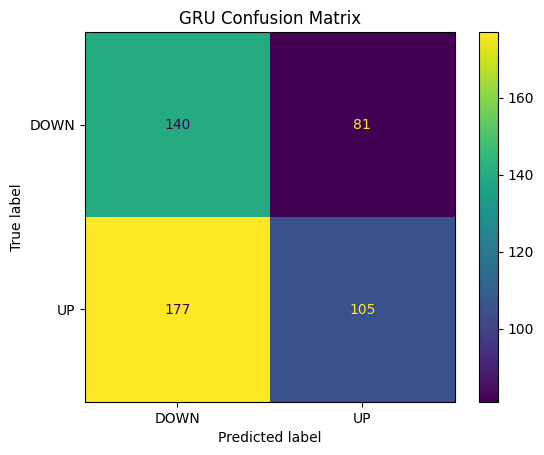

In [37]:
# Display GRU confusion matrix

cm_gru = confusion_matrix(y_test, gru_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["DOWN", "UP"]
)

disp.plot()

plt.title("GRU Confusion Matrix")
plt.show()

In [38]:
# Create a comparison table for all three models

results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU"],

    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],

    "Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],

    "Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],

    "F1 Score": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ]
})

# Display results
display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,SimpleRNN,0.437376,0.400000,0.007092,0.013937
1,LSTM,0.457256,0.666667,0.063830,0.116505
2,GRU,0.487078,0.564516,0.372340,0.448718


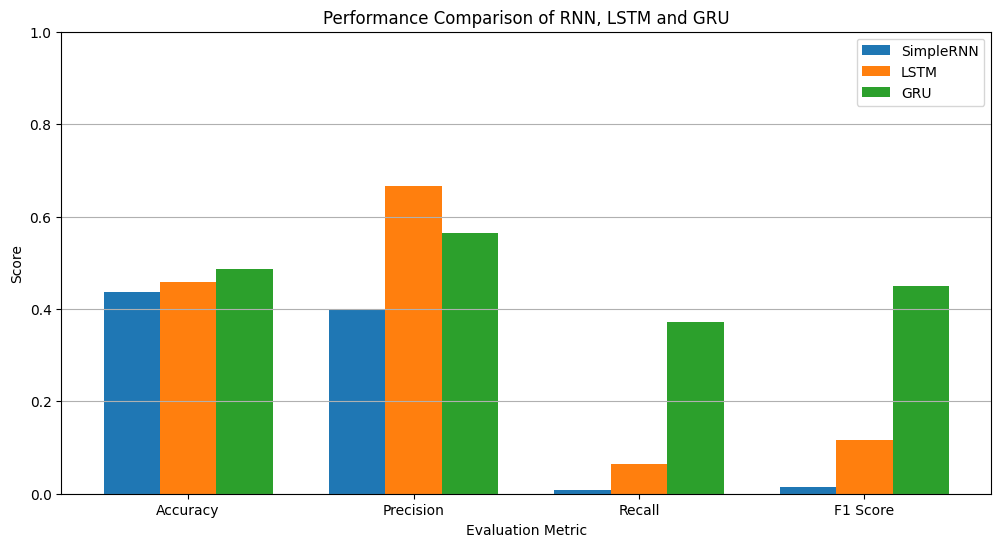

In [39]:
# Plot a comparison of the three models

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    results.iloc[0][metrics],
    width,
    label="SimpleRNN"
)

plt.bar(
    x,
    results.iloc[1][metrics],
    width,
    label="LSTM"
)

plt.bar(
    x + width,
    results.iloc[2][metrics],
    width,
    label="GRU"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Performance Comparison of RNN, LSTM and GRU")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

plt.show()

In [40]:
# Select the model with the highest F1 Score

best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_f1_score = results["F1 Score"].max()

print("Best Performing Model:", best_model_name)
print("Best F1 Score:", best_f1_score)

Best Performing Model: GRU
Best F1 Score: 0.44871794871794873


In [41]:
# Combine scaled training and testing data
# so that we have the complete historical series.

all_scaled = np.concatenate(
    [train_scaled, test_scaled]
)

# Select the most recent 30 observations
latest_sequence = all_scaled[-time_step:]

# Reshape for model input
latest_sequence = latest_sequence.reshape(
    1,
    time_step,
    1
)

# Generate predictions from all three models

rnn_latest_prob = rnn_model.predict(latest_sequence)[0][0]
lstm_latest_prob = lstm_model.predict(latest_sequence)[0][0]
gru_latest_prob = gru_model.predict(latest_sequence)[0][0]

# Convert probabilities to directions

rnn_latest_direction = "UP" if rnn_latest_prob >= 0.5 else "DOWN"
lstm_latest_direction = "UP" if lstm_latest_prob >= 0.5 else "DOWN"
gru_latest_direction = "UP" if gru_latest_prob >= 0.5 else "DOWN"

print("Next-Day Direction Predictions")
print("--------------------------------")

print(
    f"SimpleRNN: {rnn_latest_direction} "
    f"(Probability of UP = {rnn_latest_prob:.4f})"
)

print(
    f"LSTM: {lstm_latest_direction} "
    f"(Probability of UP = {lstm_latest_prob:.4f})"
)

print(
    f"GRU: {gru_latest_direction} "
    f"(Probability of UP = {gru_latest_prob:.4f})"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Next-Day Direction Predictions
--------------------------------
SimpleRNN: DOWN (Probability of UP = 0.4778)
LSTM: DOWN (Probability of UP = 0.4889)
GRU: DOWN (Probability of UP = 0.4943)


In [42]:
print("Conclusion")
print("----------")

print(
    "This assignment compared SimpleRNN, LSTM and GRU models "
    "for predicting the next-day direction of AAPL stock."
)

print(
    f"The model with the highest F1 Score was {best_model_name}, "
    f"with an F1 Score of {best_f1_score:.4f}."
)

print(
    "The models were evaluated using Accuracy, Precision, "
    "Recall and F1 Score."
)

print(
    "A chronological train-test split was used because stock "
    "market data is time-dependent."
)

print(
    "The feature scaler was fitted only on training data "
    "to prevent data leakage."
)

Conclusion
----------
This assignment compared SimpleRNN, LSTM and GRU models for predicting the next-day direction of AAPL stock.
The model with the highest F1 Score was GRU, with an F1 Score of 0.4487.
The models were evaluated using Accuracy, Precision, Recall and F1 Score.
A chronological train-test split was used because stock market data is time-dependent.
The feature scaler was fitted only on training data to prevent data leakage.
